## Modelagem

Este notebook mostra os testes que fiz antes de chegar ao modelo final. Comecei por modelos mais simples, validei tudo em 2025 e depois testei uma versao com variaveis historicas.


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


## Leitura do csv

In [3]:
caminho_arquivo = Path("../data/dados_anonimizados_2026.xlsx")

if caminho_arquivo.exists():
    df_original = pd.read_excel(caminho_arquivo)
else:
    print("Arquivo não encontrado")
    
df = df_original.copy()


## Data mensal

In [4]:
df["data"] = pd.to_datetime(
df["ano"].astype(str) + "-" +
df["mes"].astype(str) + "-01"
)

df.head()


,ano,mes,cidade_agrupada,class_segmentos,abertura_empresas,data
0,2018,1,PORTO ALEGRE,Fisioterapia,1,2018-01-01
1,2018,1,grande_sp,Turismo,11,2018-01-01
2,2018,1,PORTO ALEGRE,Intermediação,4,2018-01-01
3,2018,1,CURITIBA,Eventos,5,2018-01-01
4,2018,1,grande_sp,Fisioterapia,6,2018-01-01


## Base de modelagem

In [55]:
base_modelo = (
df
.groupby(["data", "ano", "mes", "cidade_agrupada", "class_segmentos"], as_index = False)
["abertura_empresas"]
.sum()
.sort_values(["cidade_agrupada", "class_segmentos", "data"], ascending = False)
)

base_modelo


,data,ano,mes,cidade_agrupada,class_segmentos,abertura_empresas
22945,2025-12-01,2025,12,outros,Veterinária,94
22705,2025-11-01,2025,11,outros,Veterinária,141
22466,2025-10-01,2025,10,outros,Veterinária,170
22226,2025-09-01,2025,9,outros,Veterinária,169
21986,2025-08-01,2025,8,outros,Veterinária,136
...,...,...,...,...,...,...
943,2018-05-01,2018,5,BELO HORIZONTE,Advocacia,37
707,2018-04-01,2018,4,BELO HORIZONTE,Advocacia,25
468,2018-03-01,2018,3,BELO HORIZONTE,Advocacia,26
234,2018-02-01,2018,2,BELO HORIZONTE,Advocacia,24


In [56]:
data_minima = base_modelo["data"].min()
base_modelo["t"] = (
(base_modelo["data"].dt.year - data_minima.year) * 12 + 
(base_modelo["data"].dt.month - data_minima.month)
)

base_modelo.head()


,data,ano,mes,cidade_agrupada,class_segmentos,abertura_empresas,t
22945,2025-12-01,2025,12,outros,Veterinária,94,95
22705,2025-11-01,2025,11,outros,Veterinária,141,94
22466,2025-10-01,2025,10,outros,Veterinária,170,93
22226,2025-09-01,2025,9,outros,Veterinária,169,92
21986,2025-08-01,2025,8,outros,Veterinária,136,91


## Primeiras variaveis


In [57]:
features_numericas = ["ano", "mes", "t"]
features_categoricas = ["class_segmentos", "cidade_agrupada"]
target = "abertura_empresas"


## Treino e teste

Como e um problema de previsao no tempo, treinei com os anos ate 2024 e deixei 2025 como teste, simulando uma previsao de periodo futuro.


In [58]:
treino = base_modelo["ano"] <= 2024
teste = base_modelo["ano"] == 2025

x_train = base_modelo.loc[treino , features_numericas + features_categoricas]
y_train = base_modelo.loc[treino,target]

x_test = base_modelo.loc[teste, features_numericas + features_categoricas]
y_test = base_modelo.loc[teste, target]


## Metricas de erro

Usei MAE para ver o erro medio em quantidade de empresas. Tambem usei WMAPE para ter uma leitura percentual que da mais peso aos grupos com maior volume.


In [59]:
def wmape (y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))


## Tratamento das categorias

Cidade e segmento precisam virar numeros antes de entrar no modelo.


In [60]:
preprocessamento = ColumnTransformer(
transformers = [
    ("categoricas", OneHotEncoder(handle_unknown = "ignore"), features_categoricas),
    ("numericas", "passthrough", features_numericas)
]
)


In [61]:
modelo_linear = Pipeline (
steps=[
("preprocessamento", preprocessamento),
("modelo", LinearRegression())]
)

modelo_linear.fit(x_train, y_train)
pred_linear = modelo_linear.predict(x_test)


In [62]:
mae_linear = mean_absolute_error(y_test, pred_linear)
wmape_linear = wmape(y_test, pred_linear )

print(f"O modelo errou em média {mae_linear:,.0f} aberturas por previsão")
print(f"Com uma taxa de: {wmape_linear:.2%}% de erro")


O modelo errou em média 62 aberturas por previsão
Com uma taxa de: 53.45%% de erro


## Random Forest inicial

Depois testei Random Forest usando as mesmas variaveis iniciais. A expectativa era melhorar um pouco porque esse modelo lida melhor com relacoes que nao sao tao lineares.


In [ ]:
modelo_rf = Pipeline(
steps = [
    ("preprocessamento", preprocessamento),
    ("modelo", RandomForestRegressor(
        n_estimators= 300,
        random_state = 141106,
        min_samples_leaf = 3,
        n_jobs=-1
    ))
]
)

modelo_rf.fit(x_train, y_train)
pred_rf = modelo_rf.predict(x_test)


In [64]:
mae_rf = mean_absolute_error(y_test, pred_rf)
wmape_rf = wmape(y_test, pred_rf )

print(f"O modelo errou em média {mae_rf:,.0f} aberturas por previsão")
print(f"Com uma taxa de: {wmape_rf:.2%}% de erro")


O modelo errou em média 22 aberturas por previsão
Com uma taxa de: 19.01%% de erro


## Comparacao em 2025

Montei uma tabela com o real de 2025 e as previsoes dos dois modelos.

In [ ]:
resultado_teste = base_modelo.loc[
teste,
["data", "ano", "mes", "cidade_agrupada", "class_segmentos", "abertura_empresas"]
].copy()

resultado_teste["previsao_linear"] = pred_linear
resultado_teste["previsao_rf"] = pred_rf

resultado_teste


In [66]:
resultado_teste_mensal = (
resultado_teste
.groupby("data", as_index = False)[
    ["abertura_empresas", "previsao_linear", "previsao_rf"]
]
.sum()
.sort_values("data")
)

resultado_teste_mensal


,data,abertura_empresas,previsao_linear,previsao_rf
0,2025-01-01,30992,25527.974442,24214.604351
1,2025-02-01,29356,25549.751824,24551.841297
2,2025-03-01,31680,25571.529207,24859.197150
3,2025-04-01,28032,25593.306590,24813.920192
4,2025-05-01,27820,25615.083973,24578.563797
5,2025-06-01,26033,25636.861356,24583.333819
6,2025-07-01,30922,25658.638739,24809.546666
7,2025-08-01,27946,25680.416122,24625.809574
8,2025-09-01,28849,25702.193505,24059.587022
9,2025-10-01,29680,25723.970888,23750.858487


In [67]:
mae_linear_mensal = mean_absolute_error(
resultado_teste_mensal["abertura_empresas"],
resultado_teste_mensal["previsao_linear"]
)

wmape_linear_mensal = wmape(
resultado_teste_mensal["abertura_empresas"],
resultado_teste_mensal["previsao_linear"]
)

mae_rf_mensal = mean_absolute_error(
resultado_teste_mensal["abertura_empresas"],
resultado_teste_mensal["previsao_rf"]
)

wmape_rf_mensal = wmape(
resultado_teste_mensal["abertura_empresas"],
resultado_teste_mensal["previsao_rf"]
)

print(f"Erro médio linear {mae_linear_mensal:,.0f} aberturas por mês")
print(f"Com uma taxa de: {wmape_linear_mensal:.2%}% de erro")
print("\n")
print(f"Erro médio rf {mae_rf_mensal:,.0f} aberturas por mês")
print(f"Com uma taxa de: {wmape_rf_mensal:.2%}% de erro")


Erro médio linear 3,557 aberturas por mês
Com uma taxa de: 12.73%% de erro


Erro médio rf 4,204 aberturas por mês
Com uma taxa de: 15.05%% de erro


## Real vs previsto

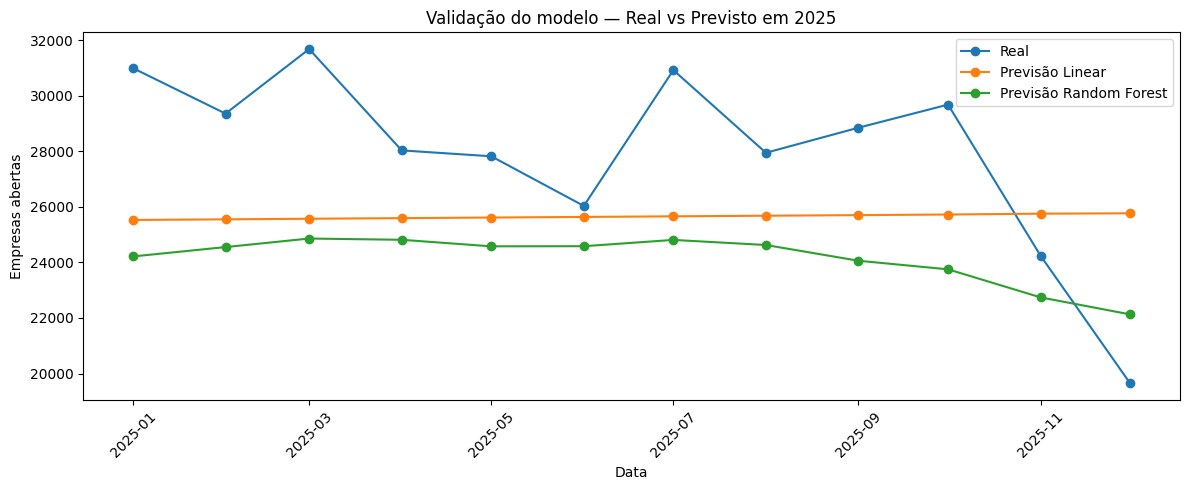

In [68]:
plt.figure(figsize=(12, 5))

plt.plot(
    resultado_teste_mensal["data"],
    resultado_teste_mensal["abertura_empresas"],
    marker="o",
    label="Real"
)

plt.plot(
    resultado_teste_mensal["data"],
    resultado_teste_mensal["previsao_linear"],
    marker="o",
    label="Previsão Linear"
)

plt.plot(
    resultado_teste_mensal["data"],
    resultado_teste_mensal["previsao_rf"],
    marker="o",
    label="Previsão Random Forest"
)

plt.title("Validação do modelo — Real vs Previsto em 2025")
plt.xlabel("Data")
plt.ylabel("Empresas abertas")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Modelo V2

Depois de testar os 2 modelos, eu decidi seguir com o Random Forest. agora vou criar mais features para o modelo ter uma analise mais precisa.


In [ ]:
base_modelo_historico = base_modelo.copy()

base_modelo_historico = (
base_modelo_historico
.sort_values(["cidade_agrupada", "class_segmentos", "data"])
)

base_modelo_historico


,data,ano,mes,cidade_agrupada,class_segmentos,abertura_empresas,t
0,2018-01-01,2018,1,BELO HORIZONTE,Advocacia,22,0
234,2018-02-01,2018,2,BELO HORIZONTE,Advocacia,24,1
468,2018-03-01,2018,3,BELO HORIZONTE,Advocacia,26,2
707,2018-04-01,2018,4,BELO HORIZONTE,Advocacia,25,3
943,2018-05-01,2018,5,BELO HORIZONTE,Advocacia,37,4
...,...,...,...,...,...,...,...
21986,2025-08-01,2025,8,outros,Veterinária,136,91
22226,2025-09-01,2025,9,outros,Veterinária,169,92
22466,2025-10-01,2025,10,outros,Veterinária,170,93
22705,2025-11-01,2025,11,outros,Veterinária,141,94


## Variaveis historicas

Criei variaveis como mes anterior, mesmo mes do ano anterior e medias dos ultimos meses. Essas colunas ajudam o modelo a enxergar padrão recente e um pouco de sazonalidade.


In [79]:
base_modelo_historico["aberturas_mes_anterior"] = (
base_modelo_historico
.groupby(["cidade_agrupada", "class_segmentos"])["abertura_empresas"]
.shift(1)
)

base_modelo_historico["aberturas_mesmo_mes_ano_anterior"] = (
base_modelo_historico
.groupby(["cidade_agrupada", "class_segmentos"])["abertura_empresas"]
.shift(12)
)

base_modelo_historico["media_ultimos_3_meses"] = (
base_modelo_historico
.groupby(["cidade_agrupada", "class_segmentos"])["abertura_empresas"]
.transform(lambda x: x.shift(1).rolling(3).mean())
)

base_modelo_historico["media_ultimos_6_meses"] = (
base_modelo_historico
.groupby(["cidade_agrupada", "class_segmentos"])["abertura_empresas"]
.transform(lambda x: x.shift(1).rolling(6).mean())
)

base_modelo_historico = base_modelo_historico.dropna().copy()


In [78]:
features_numericas_historico =[
"ano",
"mes",
"t",
"aberturas_mes_anterior",
"aberturas_mesmo_mes_ano_anterior",
"media_ultimos_3_meses",
"media_ultimos_6_meses"
]

features_categoricas_historico = ["cidade_agrupada", "class_segmentos"]

target = "abertura_empresas"
base_modelo_historico


,data,ano,mes,cidade_agrupada,class_segmentos,abertura_empresas,t
0,2018-01-01,2018,1,BELO HORIZONTE,Advocacia,22,0
234,2018-02-01,2018,2,BELO HORIZONTE,Advocacia,24,1
468,2018-03-01,2018,3,BELO HORIZONTE,Advocacia,26,2
707,2018-04-01,2018,4,BELO HORIZONTE,Advocacia,25,3
943,2018-05-01,2018,5,BELO HORIZONTE,Advocacia,37,4
...,...,...,...,...,...,...,...
21986,2025-08-01,2025,8,outros,Veterinária,136,91
22226,2025-09-01,2025,9,outros,Veterinária,169,92
22466,2025-10-01,2025,10,outros,Veterinária,170,93
22705,2025-11-01,2025,11,outros,Veterinária,141,94


In [81]:
treino_historico = base_modelo_historico["ano"] <= 2024
teste_historico = base_modelo_historico["ano"] == 2025

x_train_historico = (
base_modelo_historico
.loc[
    treino_historico, 
    features_numericas_historico + features_categoricas_historico
])

y_train_historico = (
base_modelo_historico
.loc[
    treino_historico,
    target
])

x_test_historico = (
base_modelo_historico
.loc[
    teste_historico,
    features_numericas_historico + features_categoricas_historico
])

y_test_historico = (
base_modelo_historico
.loc[
    teste_historico,
    target
]
)


In [ ]:
preprocessamento_historico =( 
ColumnTransformer(
    transformers = [
        ("categoricas", OneHotEncoder(handle_unknown = "ignore"), features_categoricas_historico),
        ("numericas", "passthrough" , features_numericas_historico)
    ]
))


In [92]:
from sklearn.pipeline import Pipeline


## Random Forest com historico

Com as variaveis historicas, o Random Forest passou a receber mais contexto antes de prever. Testei essa versao para ver se ela ficava mais proxima do comportamento real de 2025.


In [93]:
modelo_rf_historico = Pipeline(
steps=[
    ("preprocessamento", preprocessamento_historico),
    ("modelo", RandomForestRegressor(
        n_estimators=300,
        random_state=141106,
        min_samples_leaf=3,
        n_jobs=-1
    ))
])

modelo_rf_historico.fit(x_train_historico, y_train_historico)

pred_modelo_rf_historico = modelo_rf_historico.predict(x_test_historico)


In [95]:
mae_rf_historico = mean_absolute_error(y_test_historico, pred_modelo_rf_historico)
wmape_rf_historico = wmape(y_test_historico, pred_modelo_rf_historico)

print(f"O modelo errou em média {mae_rf_historico:,.0f} aberturas por previsão")
print(f"Com uma taxa de: {wmape_rf_historico:.2%}% de erro")


O modelo errou em média 18 aberturas por previsão
Com uma taxa de: 15.06%% de erro


In [ ]:
resultado_teste_historico = base_modelo_historico.loc[
teste_historico,
["data", "ano", "mes", "cidade_agrupada", "class_segmentos", "abertura_empresas"]
].copy()

resultado_teste_historico["previsao_rf_historico"] = pred_modelo_rf_historico


In [99]:
resultado_teste_historico_mensal = (
resultado_teste_historico
.groupby("data", as_index=False)[["abertura_empresas", "previsao_rf_historico"]]
.sum()
.sort_values("data")
)

resultado_teste_historico_mensal


,data,abertura_empresas,previsao_rf_historico
0,2025-01-01,30992,24696.734118
1,2025-02-01,29356,29579.417526
2,2025-03-01,31680,29316.291532
3,2025-04-01,28032,30404.731997
4,2025-05-01,27820,28564.836453
5,2025-06-01,26033,28882.536223
6,2025-07-01,30922,28689.580257
7,2025-08-01,27946,30143.435339
8,2025-09-01,28849,27972.114548
9,2025-10-01,29680,28353.485182


In [101]:
mae_rf_historico_mensal = mean_absolute_error(
resultado_teste_historico_mensal["abertura_empresas"],
resultado_teste_historico_mensal["previsao_rf_historico"]
)

wmape_rf_historico_mensal = wmape(
resultado_teste_historico_mensal["abertura_empresas"],
resultado_teste_historico_mensal["previsao_rf_historico"]
)

print(f"Erro médio rf: {mae_rf_historico_mensal:,.0f} aberturas por mês")
print(f"Com uma taxa de: {wmape_rf_historico_mensal:.2%}% de erro")


Erro médio rf: 2,464 aberturas por mês
Com uma taxa de: 8.82%% de erro


## Comparacao final

Na comparacao dos testes, a versao com Random Forest e historico foi a que fez mais sentido para seguir. Ela nao ficou perfeita, mas melhorou a leitura do mercado mensal.


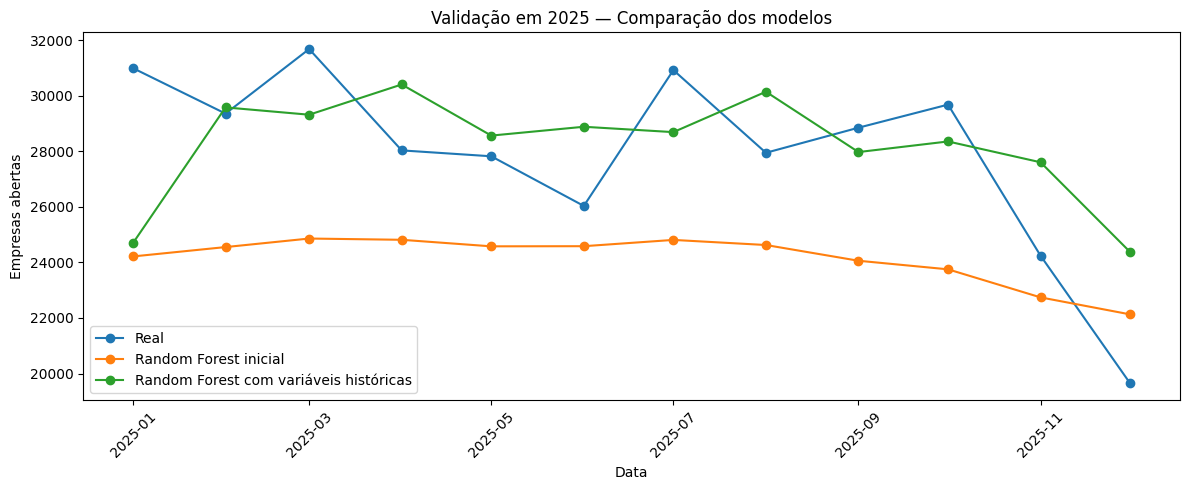

In [102]:
plt.figure(figsize=(12, 5))

plt.plot(
    resultado_teste_mensal["data"],
    resultado_teste_mensal["abertura_empresas"],
    marker="o",
    label="Real"
)

plt.plot(
    resultado_teste_mensal["data"],
    resultado_teste_mensal["previsao_rf"],
    marker="o",
    label="Random Forest inicial"
)

plt.plot(
    resultado_teste_historico_mensal["data"],
    resultado_teste_historico_mensal["previsao_rf_historico"],
    marker="o",
    label="Random Forest com variáveis históricas"
)

plt.title("Validação em 2025 — Comparação dos modelos")
plt.xlabel("Data")
plt.ylabel("Empresas abertas")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Conclusao

Este notebook ficou como registro do processo de teste. Ele mostra que a escolha do modelo final nao veio direto: primeiro comparei alternativas, vi limitacoes e depois avancei para a versao usada na projecao de 2026.
